# Inspect the DM-Control Hopper dataset

This notebook loads the memory-mapped physical Hopper dataset without initializing MuJoCo. It shows complete physical rollouts, grouped continuations with a shared initial state and first logged action, all seven circular position coordinates, all commanded/executed controls between rendered frames, and an inline animation.

In [ ]:
from pathlib import Path
import json
import math
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import HTML, display
from matplotlib import animation
from omegaconf import OmegaConf

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'implicit_nuisance').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from implicit_nuisance.data.offline_dm_control_hopper_rollout import (
    OfflineDMControlHopperNuisance,
)

SPLIT = 'train'

def is_hopper_root(path):
    path = Path(path).expanduser()
    manifest = path / 'metadata.json'
    if not manifest.is_file():
        return False
    try:
        metadata = json.loads(manifest.read_text())
    except (OSError, json.JSONDecodeError):
        return False
    required = [
        path / split / filename
        for split in ('train', 'test')
        for filename in ('images.npy', 'signal.npy', 'actions.npy', 'executed_actions.npy')
    ]
    return (
        metadata.get('format_version') == 4
        and metadata.get('dataset') == 'dm_control_hopper_nuisance'
        and all(item.is_file() for item in required)
    )

data_candidates = []
if os.environ.get('DM_CONTROL_HOPPER_ROOT'):
    data_candidates.append(Path(os.environ['DM_CONTROL_HOPPER_ROOT']))
data_candidates.extend([
    PROJECT_ROOT / 'datasets' / 'dm_control_hopper',
    PROJECT_ROOT.parent / 'datasets' / 'dm_control_hopper',
])
DATA_ROOT = next((path.resolve() for path in data_candidates if is_hopper_root(path)), None)
if DATA_ROOT is None:
    checked = '\n'.join(f'  - {path}' for path in data_candidates)
    raise FileNotFoundError(
        'Could not find a Hopper dataset. Set '
        'DM_CONTROL_HOPPER_ROOT or generate it with '
        f'./generate_mujoco_hopper_data.sh. Checked:\n{checked}'
    )

print('Project:', PROJECT_ROOT)
print('Dataset:', DATA_ROOT)

In [2]:
cfg = OmegaConf.create({
    'data': {
        'settings': {
            'root': str(DATA_ROOT),
            # Keep pixels in [0, 1] for direct visualization.
            'normalization': 'none',
        }
    }
})
dataset = OfflineDMControlHopperNuisance(cfg, split=SPLIT)
metadata = dataset.metadata

print(f'{SPLIT}: {len(dataset):,} sequences')
print('images:', dataset.images.shape, dataset.images.dtype)
print('signal:', dataset.labels['signal'].shape)
print('actions:', dataset.labels['actions'].shape)
display(metadata)

train: 100,000 sequences
images: (100000, 8, 128, 128, 3) uint8
signal: (100000, 8, 7)
actions: (100000, 8, 3, 4)


{'format_version': 4,
 'dataset': 'dm_control_hopper_nuisance',
 'environment': 'hopper',
 'task': 'hop',
 'signal_dim': 7,
 'signal_layout': {'position': [0, 7]},
 'position_names': ['root_height',
  'torso_pitch_sin',
  'torso_pitch_cos',
  'waist',
  'hip',
  'knee',
  'ankle'],
 'physics_state_dim': 14,
 'controller_state_dim': 15,
 'controller_observation_order': ['raw_position', 'touch', 'velocity'],
 'nuisance_dim': 12,
 'action_dim': 4,
 'action_alignment': 'actions[t, :] are the ordered commands for the frame t -> frame t+1 transition',
 'conditioned_action': 'actions',
 'executed_action': 'executed_actions',
 'stored_labels': ['signal',
  'position',
  'velocity',
  'touch',
  'physics_state',
  'controller_state',
  'nuisance',
  'background_seed',
  'policy_actions',
  'actions',
  'executed_actions',
  'action_noise',
  'rewards'],
 'sequence_length': 8,
 'image_size': [128, 128],
 'control_timestep': 0.02,
 'frame_skip': 3,
 'render_timestep': 0.06,
 'controller': 'LAOM C

## Inspect one complete rollout

The seven signal coordinates are root height, sine and cosine of torso pitch, waist, hip, knee, and ankle. The grid layout remains readable for the default 32-frame sequences.

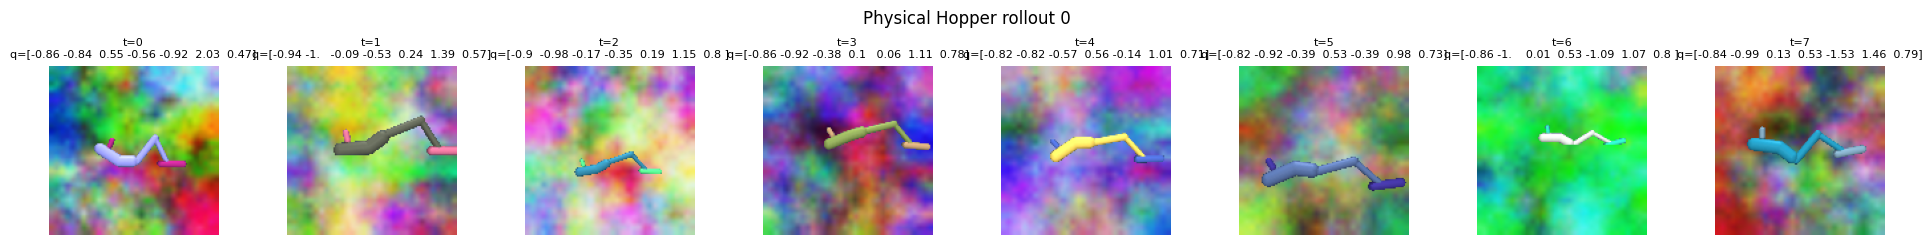

In [3]:
SEQUENCE_INDEX = 0
DISPLAY_COLUMNS = 8
frames, labels = dataset[SEQUENCE_INDEX]
sequence_length = frames.shape[0]
rows = math.ceil(sequence_length / DISPLAY_COLUMNS)

fig, axes = plt.subplots(
    rows, DISPLAY_COLUMNS,
    figsize=(2.4 * DISPLAY_COLUMNS, 2.45 * rows),
    squeeze=False,
)
for time, axis in enumerate(axes.flat):
    if time >= sequence_length:
        axis.axis('off')
        continue
    image = frames[time].permute(1, 2, 0).numpy()
    axis.imshow(np.clip(image, 0.0, 1.0))
    position = labels['position'][time].numpy()
    axis.set_title(f't={time}\nq={np.round(position, 2)}', fontsize=8)
    axis.axis('off')
fig.suptitle(f'Physical Hopper rollout {SEQUENCE_INDEX}')
fig.tight_layout()
plt.show()

## Compare stochastic continuations

Each default group of four continuations has the same initial simulator state, pixels, and logged first action. Hidden actuator noise changes the executed action and therefore the subsequent physical trajectory. Fresh appearance nuisance is also sampled after the shared first frame.

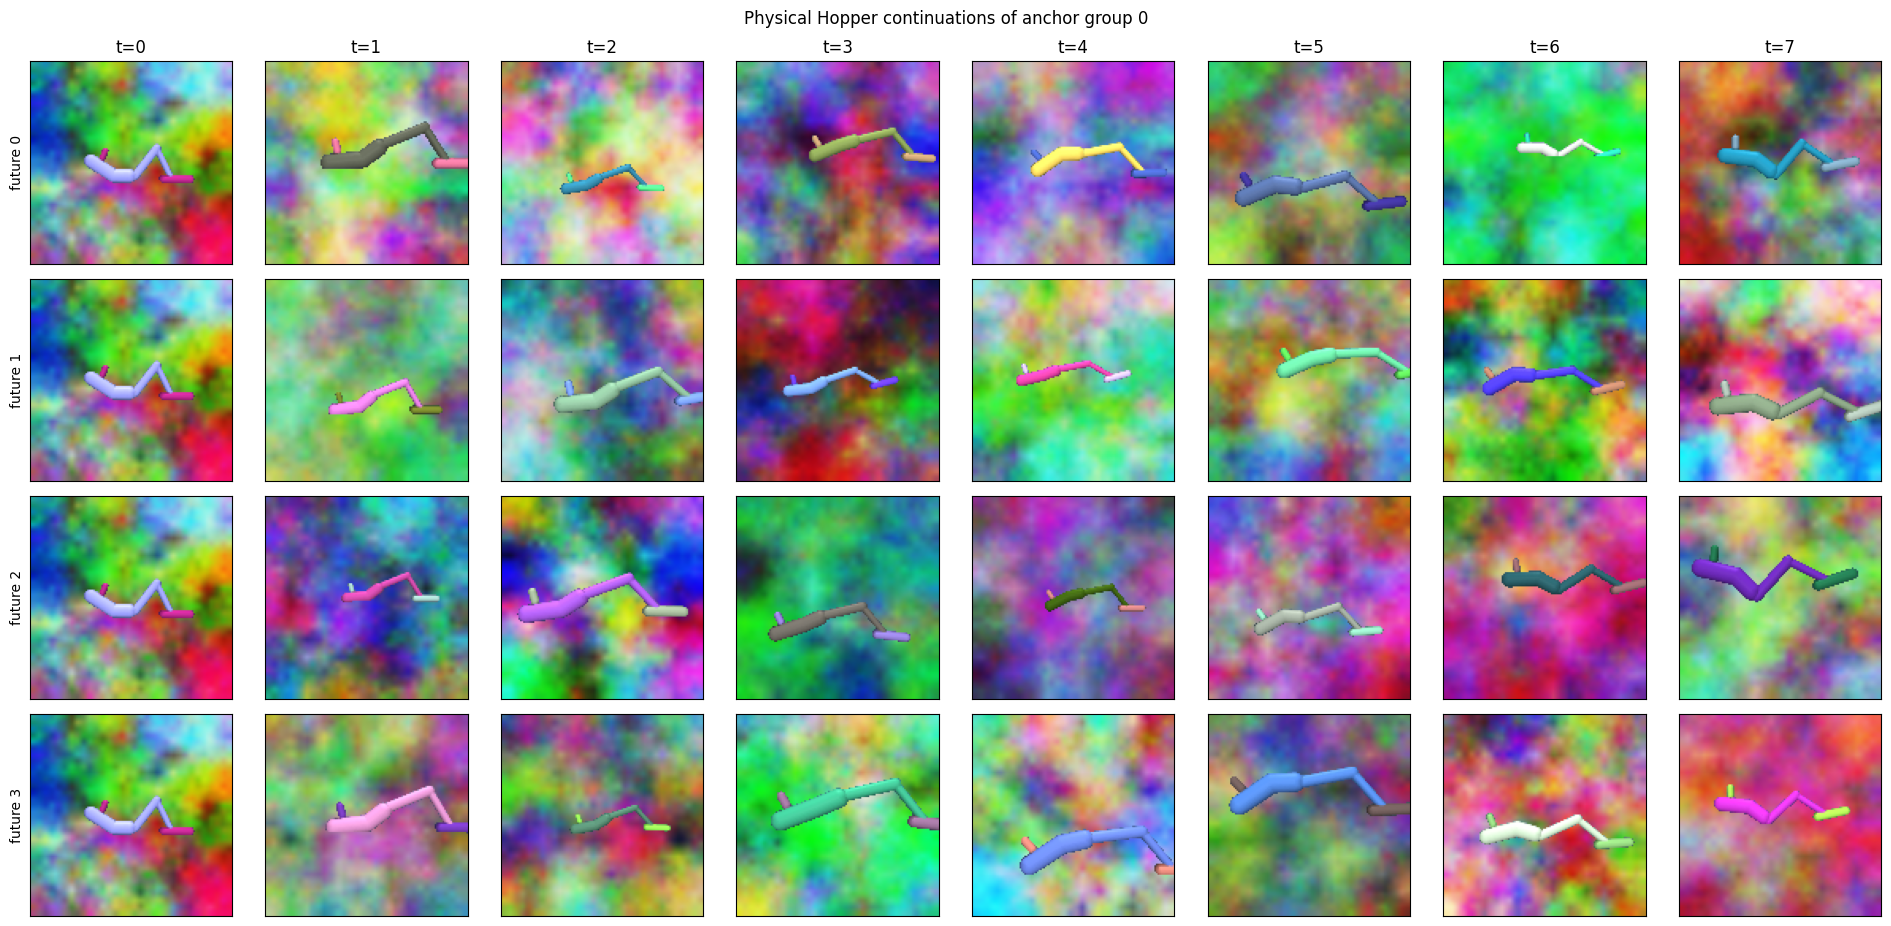

Initial pixels equal:        True
Initial state equal:         True
Logged first action equal:   True
Executed first action differs: True
Next state differs:          True


In [4]:
ANCHOR_GROUP = 0
continuations = int(metadata['continuations_per_initial_state'])
start = ANCHOR_GROUP * continuations
examples = [dataset[start + offset] for offset in range(continuations)]
display_times = np.unique(
    np.linspace(0, sequence_length - 1, min(8, sequence_length), dtype=int)
)

fig, axes = plt.subplots(
    continuations, len(display_times),
    figsize=(2.4 * len(display_times), 2.35 * continuations),
    squeeze=False,
)
for continuation, (example_frames, _) in enumerate(examples):
    for column, time in enumerate(display_times):
        axis = axes[continuation, column]
        image = example_frames[time].permute(1, 2, 0).numpy()
        axis.imshow(np.clip(image, 0.0, 1.0))
        if continuation == 0:
            axis.set_title(f't={time}')
        if column == 0:
            axis.set_ylabel(f'future {continuation}', fontsize=10)
        axis.set_xticks([])
        axis.set_yticks([])
fig.suptitle(f'Physical Hopper continuations of anchor group {ANCHOR_GROUP}')
fig.tight_layout()
plt.show()

same_initial_pixels = all(
    torch.equal(examples[0][0][0], example[0][0]) for example in examples[1:]
)
same_initial_state = all(
    torch.equal(examples[0][1]['controller_state'][0], example[1]['controller_state'][0])
    for example in examples[1:]
)
def first_control(labels, name):
    values = labels[name]
    return values[0, 0] if values.ndim == 3 else values[0]

same_logged_action = all(
    torch.equal(first_control(examples[0][1], 'actions'), first_control(example[1], 'actions'))
    for example in examples[1:]
)
different_executed_action = any(
    not torch.equal(first_control(examples[0][1], 'executed_actions'), first_control(example[1], 'executed_actions'))
    for example in examples[1:]
)
different_next_state = any(
    not torch.equal(examples[0][1]['controller_state'][1], example[1]['controller_state'][1])
    for example in examples[1:]
)
print('Initial pixels equal:       ', same_initial_pixels)
print('Initial state equal:        ', same_initial_state)
print('Logged first action equal:  ', same_logged_action)
print('Executed first action differs:', different_executed_action)
print('Next state differs:         ', different_next_state)

## Plot the physical position trajectories

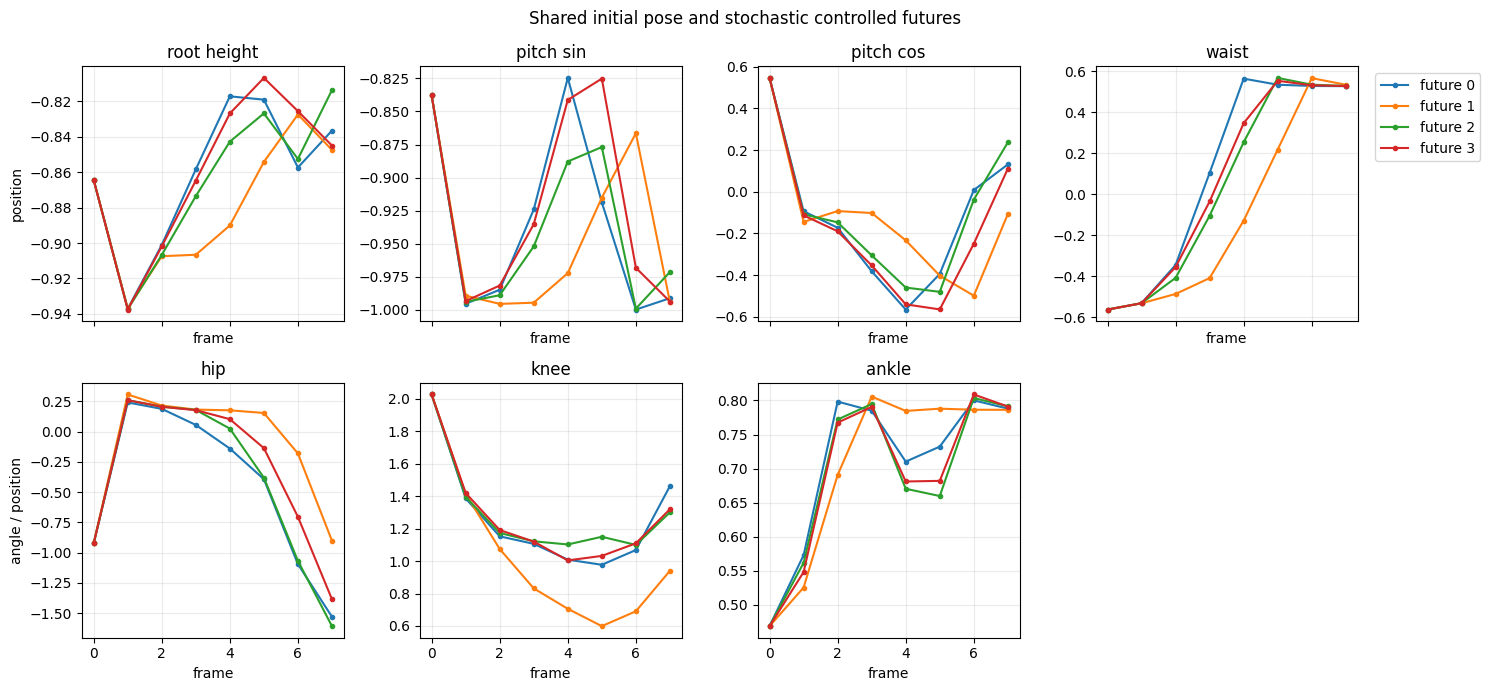

In [5]:
POSITION_NAMES = ('root height', 'pitch sin', 'pitch cos', 'waist', 'hip', 'knee', 'ankle')
times = np.arange(sequence_length)
fig, axes = plt.subplots(2, 4, figsize=(15, 7), sharex=True)
for continuation, (_, example_labels) in enumerate(examples):
    position = example_labels['position'].numpy()
    for dimension, axis in enumerate(axes.flat):
        if dimension < position.shape[1]:
            axis.plot(times, position[:, dimension], marker='.', label=f'future {continuation}')
            axis.set_title(POSITION_NAMES[dimension])
            axis.set_xlabel('frame')
            axis.grid(alpha=0.25)
axes.flat[-1].remove()
axes[0, 0].set_ylabel('position')
axes[1, 0].set_ylabel('angle / position')
axes[0, -1].legend(bbox_to_anchor=(1.04, 1), loc='upper left')
fig.suptitle('Shared initial pose and stochastic controlled futures')
fig.tight_layout()
plt.show()

## Inspect commanded and executed actions

Solid curves are the logged actions supplied to `InfoLDMAction`; dotted curves are the controls actually sent to MuJoCo after hidden dynamics noise. The final action has no saved successor and is omitted here, matching the SSL loss.

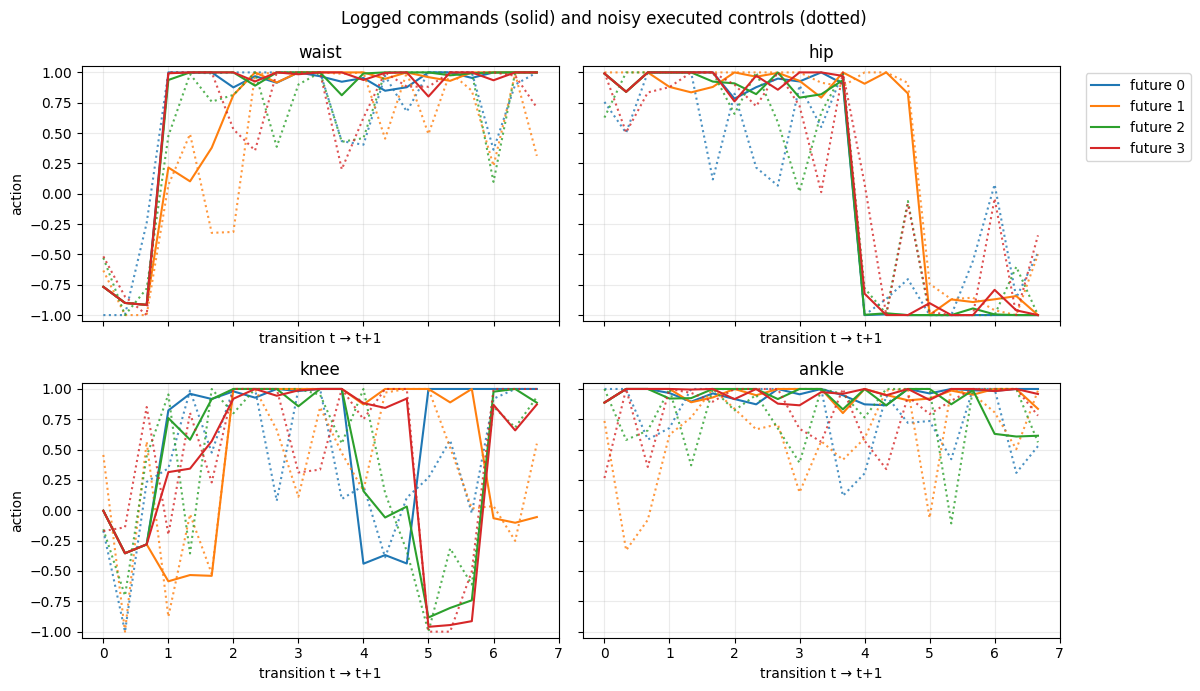

Control steps between images: 3
Configured hidden dynamics std: 0.5
Observed action-noise mean: [-0.1251  0.0238 -0.0734 -0.1974]
Observed action-noise std:  [0.2962 0.3588 0.4404 0.3313]
Clipping makes these empirical values smaller for saturated actuators.


In [6]:
ACTUATOR_NAMES = ('waist', 'hip', 'knee', 'ankle')
frame_skip = int(metadata.get('frame_skip', 1))
transition_times = np.arange((sequence_length - 1) * frame_skip) / frame_skip
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)
for continuation, (_, example_labels) in enumerate(examples):
    command = example_labels['actions'][:-1].numpy().reshape(-1, 4)
    executed = example_labels['executed_actions'][:-1].numpy().reshape(-1, 4)
    for actuator, axis in enumerate(axes.flat):
        color = f'C{continuation}'
        axis.plot(transition_times, command[:, actuator], color=color, label=f'future {continuation}')
        axis.plot(transition_times, executed[:, actuator], color=color, linestyle=':', alpha=0.8)
        axis.set_title(ACTUATOR_NAMES[actuator])
        axis.set_xlabel('transition t → t+1')
        axis.set_ylim(-1.05, 1.05)
        axis.grid(alpha=0.25)
axes[0, 0].set_ylabel('action')
axes[1, 0].set_ylabel('action')
axes[0, -1].legend(bbox_to_anchor=(1.04, 1), loc='upper left')
fig.suptitle('Logged commands (solid) and noisy executed controls (dotted)')
fig.tight_layout()
plt.show()

all_noise = torch.cat([example_labels['action_noise'][:-1].reshape(-1, 4) for _, example_labels in examples])
print('Control steps between images:', frame_skip)
print('Configured hidden dynamics std:', metadata['dynamics_noise_std'])
print('Observed action-noise mean:', np.round(all_noise.mean(0).numpy(), 4))
print('Observed action-noise std: ', np.round(all_noise.std(0).numpy(), 4))
print('Clipping makes these empirical values smaller for saturated actuators.')

## Animate the continuations side by side

In [7]:
fig, axes = plt.subplots(1, continuations, figsize=(3.2 * continuations, 3.4))
axes = np.atleast_1d(axes)
artists = []
for continuation, (example_frames, _) in enumerate(examples):
    image = example_frames[0].permute(1, 2, 0).numpy()
    artist = axes[continuation].imshow(np.clip(image, 0.0, 1.0))
    axes[continuation].set_title(f'future {continuation}')
    axes[continuation].axis('off')
    artists.append(artist)
time_text = fig.suptitle('t=0 — shared state, pixels, and logged action')
fig.tight_layout()

def update(time):
    for artist, (example_frames, _) in zip(artists, examples):
        image = example_frames[time].permute(1, 2, 0).numpy()
        artist.set_data(np.clip(image, 0.0, 1.0))
    suffix = 'shared state, pixels, and logged action' if time == 0 else 'physical and visual futures diverge'
    time_text.set_text(f't={time} — {suffix}')
    return [*artists, time_text]

movie = animation.FuncAnimation(
    fig, update, frames=sequence_length, interval=100, blit=False, repeat=True
)
plt.close(fig)
HTML(movie.to_jshtml())